<a href="https://colab.research.google.com/github/yenlung/AI-Demo/blob/master/%E3%80%90Demo01_PyTorch%E7%89%88%E3%80%91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🤖 DIVE 呆萌 AI 機器人的第一個神經網路
## MNIST 手寫辨識 × 全連結神經網路 × 你自己設計隱藏層

---

🟢 **DIVE（小劇場）**  
> 「嗨！我是 DIVE。今天我們不追求最強，我們追求『看得懂』！」  
> 「所以 CNN 先不要，先把最基本的 Dense 網路練到會！」

今天你會做到：
- 把 28×28 的手寫圖片攤平成 784 維向量
- 用 `nn.Sequential(...)` 像堆積木一樣堆神經網路（接近 tf.Keras 的感覺）
- 先用 **MSELoss + SGD**（第一堂課友善：概念直覺）
- 最後用 **Gradio + Sketchpad** 自己手寫、讓模型猜數字（成就感時間 ✨）

⚠️ **先劇透**：分類其實更適合 CrossEntropyLoss  
但第一堂課我們先用 MSE 讓「誤差平方」的概念更直覺，後面再升級。


In [1]:
# 若 Colab 沒有請取消註解
# !pip install torch torchvision gradio

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

import gradio as gr



# 1. 📦 下載 MNIST（深度學習界的 Hello World）

🟢 DIVE：  
> 「MNIST 就像你學程式的第一個 `print('Hello')`。」  
> 「做得起來，你就踏進 AI 之門了。」


In [2]:

transform = transforms.ToTensor()

train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

print("DIVE：MNIST 下載完成！")
print("訓練筆數：", len(train_ds))
print("測試筆數：", len(test_ds))


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.74MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.0MB/s]

DIVE：MNIST 下載完成！
訓練筆數： 60000
測試筆數： 10000



# 2. 👀 先給你看資料長怎樣（白底黑字版）

MNIST 原始是「黑底白字」，但我們想讓你更像在紙上寫字：  
所以顯示時用反轉 colormap：**白底黑字**。

> 小技巧：`cmap="gray_r"`（r = reversed）


In [3]:
loader_preview = DataLoader(train_ds, batch_size=64, shuffle=True)
images, labels = next(iter(loader_preview))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

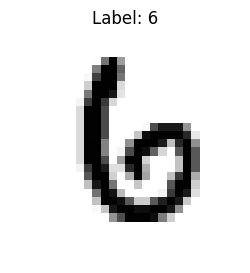

In [4]:
plt.figure(figsize=(3,3))
plt.imshow(images[0].squeeze(), cmap="gray_r")  # 白底黑字
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")


# 3. 🔧 把資料整理得更像 tf.Keras 的 x_train / y_train

🟢 DIVE：  
> 「Keras 很貼心，直接給你 numpy 陣列。」  
> 「PyTorch 也可以，我們自己做一次，順便更懂資料在幹嘛。」

我們會做：
- `x_train` 形狀變成 `(60000, 784)`
- `x_test` 形狀變成 `(10000, 784)`
- 數值縮放到 0~1


In [5]:

x_train = train_ds.data.numpy().astype(np.float32)   # (60000, 28, 28)
y_train = train_ds.targets.numpy().astype(np.int64)  # (60000,)

x_test  = test_ds.data.numpy().astype(np.float32)
y_test  = test_ds.targets.numpy().astype(np.int64)

x_train = x_train.reshape(-1, 784) / 255.0
x_test  = x_test.reshape(-1, 784) / 255.0

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)


x_train shape: (60000, 784)
y_train shape: (60000,)
x_test shape : (10000, 784)
y_test shape : (10000,)



# 4. 🏗️ 設計你的神經網路（nn.Sequential 積木版）

🟢 DIVE：  
> 「這裡就是你當『模型設計師』的地方。」  
> 「你要幾層？每層幾個神經元？你決定！」

請修改 `hidden_layers`，例如：
- `[64]`
- `[128, 64]`
- `[256, 128, 64]`


In [6]:

hidden_layers = [128, 64]   # ← 請同學自己改

layers = []
in_dim = 784

for h in hidden_layers:
    layers.append(nn.Linear(in_dim, h))
    layers.append(nn.ReLU())
    in_dim = h

layers.append(nn.Linear(in_dim, 10))

# ⚠️ 因為今天用 MSE（搭配 one-hot），先加 Softmax 讓輸出變成機率
# （未來若改成 CrossEntropyLoss，請把 Softmax 移除）
layers.append(nn.Softmax(dim=1))


In [7]:
model = nn.Sequential(*layers)
print(model)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
  (5): Softmax(dim=1)
)



# 5. ⚙️ 第一堂課設定：MSE + SGD（像 Keras compile 那樣乾淨）

你要的「兩行寫法」就長這樣：

```python
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.087)
```

🟢 DIVE：  
> 「MSE：猜錯就罰平方（直覺）」  
> 「SGD：最純的梯度下降（基本功）」

👉 之後請同學自己改成：CrossEntropy / Adam 來做比較實驗。


In [8]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.087)  # 參考你原 TF 版本的 learning_rate



# 6. 🔥 開始訓練（PyTorch 版手動 fit）

🟢 DIVE：  
> 「Keras 的 fit 很香，但 PyTorch 的訓練迴圈會讓你更懂反向傳播。」

因為用 MSE，所以要把 y 做成 one-hot 向量。


In [9]:
x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=128, shuffle=True)


In [12]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0.0

    for xb, yb in train_loader:
        y_onehot = torch.zeros((yb.size(0), 10), dtype=torch.float32)
        y_onehot.scatter_(1, yb.view(-1, 1), 1.0)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, y_onehot)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1:2d} | loss = {total_loss:.4f}")

Epoch  1 | loss = 33.2722
Epoch  2 | loss = 27.4682
Epoch  3 | loss = 20.9032
Epoch  4 | loss = 15.9934
Epoch  5 | loss = 12.9842



# 7. 🎯 測試準確率


In [13]:
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

with torch.no_grad():
    pred = model(x_test_t)
    y_hat = pred.argmax(dim=1)
    acc = (y_hat == y_test_t).float().mean().item()

print(f"測試準確率：{acc*100:.2f}%")


測試準確率：86.45%



# 8. 🎨 Gradio：用 Sketchpad 真的手寫、讓模型猜（對齊 TF 版本做法）

重點：`gr.Sketchpad()` 回傳的是一個 dict，圖在 **`inp["layers"][0]`**。  
這段我們就照你原本 TensorFlow 版本那樣處理（透明背景補白、轉灰階、縮 28×28、反相、攤平、縮放）。


In [14]:
def resize_image(inp):
    # ✅ 對齊你 TF 版本：圖在 inp["layers"][0]
    image = np.array(inp["layers"][0], dtype=np.float32).astype(np.uint8)

    image_pil = Image.fromarray(image)

    # Alpha 通道補白底（避免透明背景造成怪邊）
    if image_pil.mode == "RGBA":
        background = Image.new("RGB", image_pil.size, (255, 255, 255))
        background.paste(image_pil, mask=image_pil.split()[3])
        image_pil = background

    # 灰階 + resize 到 28×28
    image_gray = image_pil.convert("L")
    img_array = np.array(image_gray.resize((28, 28), resample=Image.LANCZOS))

    # 配合 MNIST：把你畫的黑字白底反相成黑底白字
    img_array = 255 - img_array

    # 攤平 + 縮放到 0~1
    img_array = img_array.reshape(1, 784).astype(np.float32) / 255.0
    return img_array

def recognize_digit(inp):
    img = resize_image(inp)
    x = torch.tensor(img, dtype=torch.float32)

    with torch.no_grad():
        p = model(x).numpy().flatten()

    labels = list("0123456789")
    return {labels[i]: float(p[i]) for i in range(10)}

iface = gr.Interface(
    fn=recognize_digit,
    inputs=gr.Sketchpad(),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST 手寫辨識（DIVE 版）",
    description="請在畫板上繪製數字（例如 0~9）"
)

iface.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6bcf15d68a0d158525.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6bcf15d68a0d158525.gradio.live



# 9. 🧪 延伸實驗（請同學自己改）

你可以把這兩行改成更適合分類的版本：

```python
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
```

⚠️ 但注意：如果你改成 CrossEntropyLoss，**請把模型最後那層 Softmax 拿掉**（CrossEntropy 會自己處理）。
